In [ ]:
# cd "/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/discrete/"

/storage/project/r-js130-0/pagrawala6/0_current_best/discrete


In [1]:
import duckdb
import numpy as np
import pandas as pd

HIT_conn = duckdb.connect('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/hitran_oxygen1616_schumannrunge.duckdb')
duo_conn = duckdb.connect('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/duo_oxygen1616_schumannrunge_finalrun.duckdb')
conns = [HIT_conn, duo_conn]
conns = [duo_conn]
table_names = ['hitran_transitions_schumann_runge', 'duo_oxygen1616_schumannrunge']
table_names = [ 'duo_oxygen1616_schumannrunge']

kB = 1.380_649e-23  # J/K 

# T_list = [296.0, 900.0]  # Temperatures to loop over

# Q_list = [218.61]  # Partition functions (dummy for 500)

gamma = 2 #fixed line shape parameter
sensing_nu_nm = 633 #sensing wavelength in nm
sensing_nu = 1e9/sensing_nu_nm #sensing wavenumber in m-1
tol = 1e-6

dfs = [
    conn.execute(f"SELECT * FROM {table} where up_energy<57840").fetchdf()
    for conn, table in zip(conns, table_names)
]
dfs[0]

,idx,line_pos,A,Strength,up_el,up_v,up_J,up_lambda,up_sigma,up_omega,up_energy,down_el,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,Intensity
0,0,54659.5127,1.026801e+03,6.014618e-05,B3Sigma-,9,1.0,0.0,-1.0,-1.0,54662.3866,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,1.926987e-22
1,1,55105.0711,1.499359e+03,8.571365e-05,B3Sigma-,10,1.0,0.0,-1.0,-1.0,55107.9450,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,2.768513e-22
2,2,57037.8441,1.363856e+03,7.030697e-05,B3Sigma-,18,1.0,0.0,-1.0,-1.0,57040.7180,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,2.350533e-22
3,3,53142.8856,1.820051e+02,1.160025e-05,B3Sigma-,6,1.0,0.0,-1.0,-1.0,53145.7595,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,3.613410e-23
4,4,56630.1915,3.459317e+03,1.822071e-04,B3Sigma-,15,1.0,0.0,-1.0,-1.0,56633.0654,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,6.048089e-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494977,711683,7399.9824,2.031837e-28,3.373471e-31,B3Sigma-,0,105.0,0.0,-1.0,-1.0,57700.3033,X3Sigma-,39,106.0,0.0,0.0,0.0,50300.3209,1.891254e-57
494978,711725,5629.1376,6.328905e-04,2.387169e-06,B3Sigma-,0,105.0,0.0,-1.0,-1.0,57700.3033,X3Sigma-,38,106.0,0.0,1.0,1.0,52071.1657,5.024372e-33
494979,711778,4960.4413,2.204197e-29,1.214982e-31,B3Sigma-,0,105.0,0.0,-1.0,-1.0,57700.3033,X3Sigma-,40,106.0,0.0,0.0,0.0,52739.8620,1.698411e-58
494980,711824,2300.5670,2.344806e-05,1.295634e-06,B3Sigma-,0,105.0,0.0,-1.0,-1.0,57700.3033,X3Sigma-,41,106.0,0.0,0.0,0.0,55399.7363,2.182729e-34


In [2]:
max_down_J = dfs[0]['down_J'].max()


print("Max value of down_J:", max_down_J)

Max value of down_J: 106.0


In [3]:
discrete_grouped = dfs[0].groupby(
    ['down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy']
).agg({
    'A': list,
    'line_pos': list,
    'up_energy': list,      # optional, if you want to retain upper state quantum numbers
    'up_J': list
    # add more columns as needed
}).reset_index()

discrete_grouped

,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,A,line_pos,up_energy,up_J
0,0,0.0,0.0,0.0,0.0,2.8739,"[1026.80094, 1499.35915, 1363.85647, 182.00508...","[54659.5127, 55105.0711, 57037.8441, 53142.885...","[54662.3866, 55107.945, 57040.718, 53145.7595,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
1,0,1.0,0.0,1.0,1.0,2.8739,"[10377.9495, 546.015263, 3080.40282, 4091.5694...","[56630.1915, 53142.8856, 54659.5127, 57037.844...","[56633.0654, 53145.7595, 54662.3866, 57040.718...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
2,0,2.0,0.0,0.0,0.0,17.2428,"[2.33412738e-21, 9.74220748e-20, 4.78970197e-2...","[55090.7022, 54645.1438, 56615.8227, 53128.516...","[55107.945, 54662.3866, 56633.0654, 53145.7595...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
3,0,2.0,0.0,1.0,1.0,2.8739,"[7496.79577, 17296.5825, 910.025438, 6819.2823...","[55105.0711, 56630.1915, 53142.8856, 57037.844...","[55107.945, 56633.0654, 53145.7595, 57040.718,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
4,0,3.0,0.0,1.0,1.0,17.2428,"[16617.2481, 6617.62801, 4926.38552, 7193.2886...","[56618.6466, 57025.1446, 54649.0907, 55094.483...","[56635.8894, 57042.3873, 54666.3334, 55111.726...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ..."
...,...,...,...,...,...,...,...,...,...,...
6717,42,84.0,0.0,0.0,0.0,52838.8711,"[1.06001709e-28, 1.4581916e-05, 3.63950368e-31...","[4808.0049, 4258.4696, 1867.5768, 2704.8193, 3...","[57646.8759, 57097.3406, 54706.4479, 55543.690...","[83.0, 83.0, 83.0, 83.0, 83.0, 83.0, 83.0, 83...."
6718,42,88.0,0.0,0.0,0.0,54218.9929,"[3.41362863e-29, 9.53679675e-33, 3.38898811e-0...","[3546.293, 990.2004, 3336.7878, 2637.1069, 183...","[57765.2859, 55209.1933, 57555.7807, 56856.099...","[87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87...."
6719,42,96.0,0.0,0.0,0.0,57207.4401,"[1.33402302e-33, 1.34127003e-32, 1.58713652e-0...","[118.1262, 593.33, 381.4072, 621.0068, 628.913...","[57325.5663, 57800.7701, 57588.8472, 57828.446...","[95.0, 95.0, 95.0, 95.0, 95.0, 96.0, 96.0, 97...."
6720,42,100.0,0.0,0.0,0.0,53935.3019,"[1.37918554e-27, 1.66794621e-28, 0.00011685023...","[3452.7078, 2895.0181, 3730.8702, 3180.8278, 3...","[57388.0097, 56830.32, 57666.172, 57116.1297, ...","[99.0, 99.0, 99.0, 99.0, 100.0, 100.0, 101.0, ..."


In [4]:
import pandas as pd

# 1) Filter J = 0 and v range
df_vib = discrete_grouped[
    (discrete_grouped['down_J'] == 0) &
    (discrete_grouped['down_v'].between(0, 20))
]

# 2) Get minimum energy per vibrational level
vib_energies = (
    df_vib
    .groupby('down_v')['down_energy']
    .min()
    .reset_index()
    .sort_values('down_v')
)
vib_energies['down_energy'] = vib_energies['down_energy'] - 2.8739

print(vib_energies)

    down_v  down_energy
0        0       0.0000
1        1    1556.5833
2        2    3086.2416
3        3    4596.8598
4        4    6084.1886
5        5    7548.2948
6        6    8989.6449
7        7   10408.4501
8        8   11804.7729
9        9   13178.2704
10      10   14528.5013
11      11   15855.2428
12      12   17158.5527
13      13   18438.5624
14      14   19695.1485
15      15   20928.2146
16      16   22137.6018
17      17   23323.0549
18      18   24484.2576
19      19   25620.7956
20      20   26732.2882


In [5]:
# compute partition function 
down_J_list = discrete_grouped['down_J'].tolist()
down_energy_list = discrete_grouped['down_energy'].tolist()
down_lambda_list = discrete_grouped['down_lambda'].tolist()
down_sigma_list = discrete_grouped['down_sigma'].tolist()
down_omega_list = discrete_grouped['down_omega'].tolist()
down_energy_list = [energy-2.8739 for energy in down_energy_list]

# Global variables to store energy data (loaded once)
energies_m = None
J_vals = None

def load_energy_data():
    """Load energy levels from database once"""
    global energies_m, J_vals
    if energies_m is None:
        
        
        energies_cm = list(down_energy_list)
        J_vals = list(down_J_list)
        energies_m = [(energy_cm) / 1e-2 for energy_cm in energies_cm]
        print(f"Loaded {len(energies_cm)} energy levels")

def Q(T_Kelvin, batch_size=500, tolerance=1e-5, verbose=False):

    """
    Calculate partition function Q for a given temperature
    
    Parameters:
    T_Kelvin: Temperature in Kelvin
    batch_size: Number of energy levels to process per batch
    tolerance: Convergence tolerance
    verbose: Print convergence information
    
    Returns:
    Q: Partition function value
    """
    # Load data if not already loaded
    load_energy_data()
    
    Q_val = 0.0
    Q_old = []
    
    if verbose:
        print(f"Calculating Q for T = {T_Kelvin} K")
    # Constants
    k_b = 1.380649e-23  # Boltzmann constant in J/K
    h = 6.62607015e-34  # Planck constant in J·s
    c = 299792458       # Speed of light in m/s
    cm_to_m = 1e-2      # Convert cm^-1 to m^-1
    # Loop in batches, convert each batch to Joules, accumulate Q
    for i in range(0, len(energies_m), batch_size):
        batch_m = energies_m[i:i + batch_size]
        batch_J = J_vals[i:i + batch_size]
        
        # Convert from cm^-1 to J: E(J) = E(cm^-1) * 100 * h * c
        batch_joules = [(e) * h * c for e in batch_m]
        
        # Calculate partition function contribution for each energy level
        batch_contribution = [(np.exp(-(e)/(k_b * T_Kelvin))) for e in batch_joules]
        batch_degeneracies = [2*J + 1 for J in batch_J]  # Degeneracy factor for each J
        batch_contribution = [contrib * deg for contrib, deg in zip(batch_contribution, batch_degeneracies)]
        
        batch_sum = sum(batch_contribution)
        
        Q_old.append(Q_val)
        Q_val += batch_sum
        
        # Check for convergence
        if abs(Q_val - Q_old[-1]) < tolerance:
            
            if verbose:
                print(f"Converged after batch {len(Q_old)}")
            break
    
    if verbose:
    
        print(f"Final Q = {Q_val:.6f}")


    
    return Q_val

Q(300)

Loaded 6722 energy levels


221.53125222437387

In [16]:
import numpy as np
import pandas as pd

# --- Constants ---
epsilon_0 = 8.8541878128e-12  # F/m
h = 6.62607015e-34  # J·s
c = 299792458       # m/s
me = 9.10938356e-31 # kg
e = 1.602176634e-19 # C

# The target sensing wavelengths in nm
wavelengths = {
    'pol_632.8nm': 632.8, # He-Ne
    'pol_532.0nm': 532.0, # Nd:YAG second harmonic
    'pol_400nm': 400.0,  # Ti:Sapphire or frequency-doubled dye laser
    'pol_388nm': 388.0  # Ti:Sapphire or frequency-doubled dye laser
}

def calculate_polarizability_sums(row):
    """
    Computes the polarizability sum for a single lower level (row) 
    across all discrete upper states, for multiple wavelengths.
    """
    # Extract lower state properties
    down_J = row['down_J']
    
    # Extract transition arrays (cast to numpy arrays for vectorized math)
    up_J = np.array(row['up_J'])
    A = np.array(row['A']) 
    line_pos = np.array(row['line_pos'])
    
    # Physics / Unit conversions (strictly kept from your original code)
    line_pos_m = line_pos / 0.01  # Converted from cm^-1 to m^-1
    omega = 2 * np.pi * c * line_pos_m
    
    g2_over_g1 = (2 * up_J + 1) / (2 * down_J + 1)
    multiplier = 2 * np.pi * epsilon_0 * me * c**3 / e**2  # SI angular frequency form
    
    # Calculate oscillator strength for all transitions from this lower state
    oscillator_strength = (multiplier * A * g2_over_g1) / (omega ** 2)
    
    # Linewidth parameter (kept exactly as your original)
    gamma = 0 
    gamma_angular = 2 * np.pi * c * gamma * 100 
    
    # Dictionary to store the sum for each wavelength
    pol_results = {}
    
    for pol_key, wl_nm in wavelengths.items():
        sensing_nu = 1e9 / wl_nm
        sensing_omega = sensing_nu * 2 * np.pi * c
        
        # Calculate denominators
        denominator_1 = omega - sensing_omega - (1j * gamma_angular / 2)
        denominator_2 = omega + sensing_omega + (1j * gamma_angular / 2)
        denominator = denominator_1 * denominator_2
        
        # Sum (oscillator_strength / denominator) over all upper states
        # No population effects included here.
        pol_sum = np.sum(oscillator_strength / denominator)
        pol_results[pol_key] = pol_sum
        
    return pd.Series(pol_results)

# Apply the function to the database to generate the 4 new columns
discrete_grouped[['pol_632.8nm', 'pol_532.0nm', 'pol_400nm', 'pol_388nm']] = discrete_grouped.apply(calculate_polarizability_sums, axis=1)

# Display the first few rows to verify
(discrete_grouped[['down_v', 'down_J', 'down_energy','down_lambda', 'down_sigma', 'down_omega', 'pol_632.8nm', 'pol_532.0nm', 'pol_400nm', 'pol_388nm']].head(7))

,down_v,down_J,down_energy,down_lambda,down_sigma,down_omega,pol_632.8nm,pol_532.0nm,pol_400nm,pol_388nm
0,0,0.0,2.8739,0.0,0.0,0.0,1.044379e-36+0.000000e+ 00j,1.083109e-36+0.000000e+ 00j,1.199814e-36+0.000000e+ 00j,1.218795e-36+0.000000e+ 00j
1,0,1.0,2.8739,0.0,1.0,1.0,1.044379e-36+0.000000e+ 00j,1.083109e-36+0.000000e+ 00j,1.199814e-36+0.000000e+ 00j,1.218795e-36+0.000000e+ 00j
2,0,2.0,17.2428,0.0,0.0,0.0,1.047848e-36+0.000000e+ 00j,1.086714e-36+0.000000e+ 00j,1.203831e-36+0.000000e+ 00j,1.222879e-36+0.000000e+ 00j
3,0,2.0,2.8739,0.0,1.0,1.0,1.044379e-36+0.000000e+ 00j,1.083109e-36+0.000000e+ 00j,1.199814e-36+0.000000e+ 00j,1.218795e-36+0.000000e+ 00j
4,0,3.0,17.2428,0.0,1.0,1.0,1.047848e-36+0.000000e+ 00j,1.086714e-36+0.000000e+ 00j,1.203831e-36+0.000000e+ 00j,1.222879e-36+0.000000e+ 00j
5,0,4.0,43.1043,0.0,0.0,0.0,1.054119e-36+0.000000e+ 00j,1.093230e-36+0.000000e+ 00j,1.211093e-36+0.000000e+ 00j,1.230263e-36+0.000000e+ 00j
6,0,4.0,17.2428,0.0,1.0,1.0,1.047848e-36+0.000000e+ 00j,1.086714e-36+0.000000e+ 00j,1.203831e-36+0.000000e+ 00j,1.222879e-36+0.000000e+ 00j


In [17]:
# 1. Identify complex columns
complex_cols = discrete_grouped.select_dtypes(include=['complex']).columns

# 2. Split them: Real part stays in the original name, Imaginary gets a suffix
for col in complex_cols:
    # We create the imaginary column first
    discrete_grouped[f"{col}_imag"] = discrete_grouped[col].apply(lambda x: x.imag)
    # Then overwrite the original with just the real part
    discrete_grouped[col] = discrete_grouped[col].apply(lambda x: x.real)

discrete_grouped

,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,A,line_pos,up_energy,up_J,pol_632.8nm,pol_532.0nm,pol_400nm,pol_388nm,pol_632.8nm_imag,pol_532.0nm_imag,pol_400nm_imag,pol_388nm_imag
0,0,0.0,0.0,0.0,0.0,2.8739,"[1026.80094, 1499.35915, 1363.85647, 182.00508...","[54659.5127, 55105.0711, 57037.8441, 53142.885...","[54662.3866, 55107.945, 57040.718, 53145.7595,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.044379e-36,1.083109e-36,1.199814e-36,1.218795e-36,0.0,0.0,0.0,0.0
1,0,1.0,0.0,1.0,1.0,2.8739,"[10377.9495, 546.015263, 3080.40282, 4091.5694...","[56630.1915, 53142.8856, 54659.5127, 57037.844...","[56633.0654, 53145.7595, 54662.3866, 57040.718...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.044379e-36,1.083109e-36,1.199814e-36,1.218795e-36,0.0,0.0,0.0,0.0
2,0,2.0,0.0,0.0,0.0,17.2428,"[2.33412738e-21, 9.74220748e-20, 4.78970197e-2...","[55090.7022, 54645.1438, 56615.8227, 53128.516...","[55107.945, 54662.3866, 56633.0654, 53145.7595...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.047848e-36,1.086714e-36,1.203831e-36,1.222879e-36,0.0,0.0,0.0,0.0
3,0,2.0,0.0,1.0,1.0,2.8739,"[7496.79577, 17296.5825, 910.025438, 6819.2823...","[55105.0711, 56630.1915, 53142.8856, 57037.844...","[55107.945, 56633.0654, 53145.7595, 57040.718,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.044379e-36,1.083109e-36,1.199814e-36,1.218795e-36,0.0,0.0,0.0,0.0
4,0,3.0,0.0,1.0,1.0,17.2428,"[16617.2481, 6617.62801, 4926.38552, 7193.2886...","[56618.6466, 57025.1446, 54649.0907, 55094.483...","[56635.8894, 57042.3873, 54666.3334, 55111.726...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...",1.047848e-36,1.086714e-36,1.203831e-36,1.222879e-36,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6717,42,84.0,0.0,0.0,0.0,52838.8711,"[1.06001709e-28, 1.4581916e-05, 3.63950368e-31...","[4808.0049, 4258.4696, 1867.5768, 2704.8193, 3...","[57646.8759, 57097.3406, 54706.4479, 55543.690...","[83.0, 83.0, 83.0, 83.0, 83.0, 83.0, 83.0, 83....",-1.215381e-41,-8.389628e-42,-4.630370e-42,-4.348818e-42,0.0,0.0,0.0,0.0
6718,42,88.0,0.0,0.0,0.0,54218.9929,"[3.41362863e-29, 9.53679675e-33, 3.38898811e-0...","[3546.293, 990.2004, 3336.7878, 2637.1069, 183...","[57765.2859, 55209.1933, 57555.7807, 56856.099...","[87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87....",-7.351189e-42,-5.133867e-42,-2.866657e-42,-2.694700e-42,0.0,0.0,0.0,0.0
6719,42,96.0,0.0,0.0,0.0,57207.4401,"[1.33402302e-33, 1.34127003e-32, 1.58713652e-0...","[118.1262, 593.33, 381.4072, 621.0068, 628.913...","[57325.5663, 57800.7701, 57588.8472, 57828.446...","[95.0, 95.0, 95.0, 95.0, 95.0, 96.0, 96.0, 97....",-3.700738e-43,-2.614592e-43,-1.477467e-43,-1.390103e-43,0.0,0.0,0.0,0.0
6720,42,100.0,0.0,0.0,0.0,53935.3019,"[1.37918554e-27, 1.66794621e-28, 0.00011685023...","[3452.7078, 2895.0181, 3730.8702, 3180.8278, 3...","[57388.0097, 56830.32, 57666.172, 57116.1297, ...","[99.0, 99.0, 99.0, 99.0, 100.0, 100.0, 101.0, ...",-3.773675e-42,-2.627411e-42,-1.462490e-42,-1.374432e-42,0.0,0.0,0.0,0.0


In [18]:
# 3. Connect and Write to DuckDB
duckdb_conn = duckdb.connect('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb')

# Note: We must quote any column name with a "." inside the EXCLUDE list
duckdb_conn.execute("""
CREATE OR REPLACE TABLE discrete_polarizabilities AS 
SELECT * EXCLUDE (A, line_pos, up_energy, up_J) 
FROM discrete_grouped
""")

duckdb_conn.close()
print("Table created successfully with Real and Imaginary components.")

Table created successfully with Real and Imaginary components.


In [19]:
duckdb_conn = duckdb.connect('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb')
display(duckdb_conn.execute("SELECT * FROM discrete_polarizabilities LIMIT 5").fetchdf())
duckdb_conn.close()

,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,pol_632.8nm,pol_532.0nm,pol_400nm,pol_388nm,pol_632.8nm_imag,pol_532.0nm_imag,pol_400nm_imag,pol_388nm_imag
0,0,0.0,0.0,0.0,0.0,2.8739,1.044379e-36,1.083109e-36,1.199814e-36,1.218795e-36,0.0,0.0,0.0,0.0
1,0,1.0,0.0,1.0,1.0,2.8739,1.044379e-36,1.083109e-36,1.199814e-36,1.218795e-36,0.0,0.0,0.0,0.0
2,0,2.0,0.0,0.0,0.0,17.2428,1.047848e-36,1.086714e-36,1.203831e-36,1.222879e-36,0.0,0.0,0.0,0.0
3,0,2.0,0.0,1.0,1.0,2.8739,1.044379e-36,1.083109e-36,1.199814e-36,1.218795e-36,0.0,0.0,0.0,0.0
4,0,3.0,0.0,1.0,1.0,17.2428,1.047848e-36,1.086714e-36,1.203831e-36,1.222879e-36,0.0,0.0,0.0,0.0


In [20]:
num_unique_lower_levels = discrete_grouped[[
    'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
]].drop_duplicates().shape[0]

print(f"Number of unique lower levels: {num_unique_lower_levels}")


Number of unique lower levels: 6722


In [21]:
# Multiplier code, run only once
import numpy as np

# Calculate the constant scalar
# Multiplier = (e^2 * 1e30) / (me * epsilon_0)
MULTIPLIER = (e**2 * 1e30) / (me * epsilon_0)

print(f"Calculated Multiplier: {MULTIPLIER:.4e}")

import duckdb

# Connect to your database
db_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'
duckdb_conn = duckdb.connect(db_path)

# Apply the multiplier to the Real and Imaginary components
# Assuming you have both pol_xxx and pol_xxx_imag columns
columns_to_update = [
    "pol_532.0nm", "pol_532.0nm_imag",
    "pol_632.8nm", "pol_632.8nm_imag",
    "pol_400nm", "pol_400nm_imag",
    "pol_388nm", "pol_388nm_imag"

]

# Construct the SET clause: "column" = "column" * MULTIPLIER
set_clause = ", ".join([f'"{col}" = "{col}" * {MULTIPLIER}' for col in columns_to_update])

try:
    duckdb_conn.execute(f"UPDATE discrete_polarizabilities SET {set_clause}")
    print("Successfully multiplied columns by physical constants.")
except Exception as e:
    print(f"Error: {e}")
    print("Ensure all column names (including _imag) exist in the table.")

# Verify a sample
display(duckdb_conn.execute("SELECT * FROM discrete_polarizabilities LIMIT 1").df())

duckdb_conn.close()

Calculated Multiplier: 3.1826e+33
Successfully multiplied columns by physical constants.


,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,pol_632.8nm,pol_532.0nm,pol_400nm,pol_388nm,pol_632.8nm_imag,pol_532.0nm_imag,pol_400nm_imag,pol_388nm_imag
0,0,0.0,0.0,0.0,0.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0


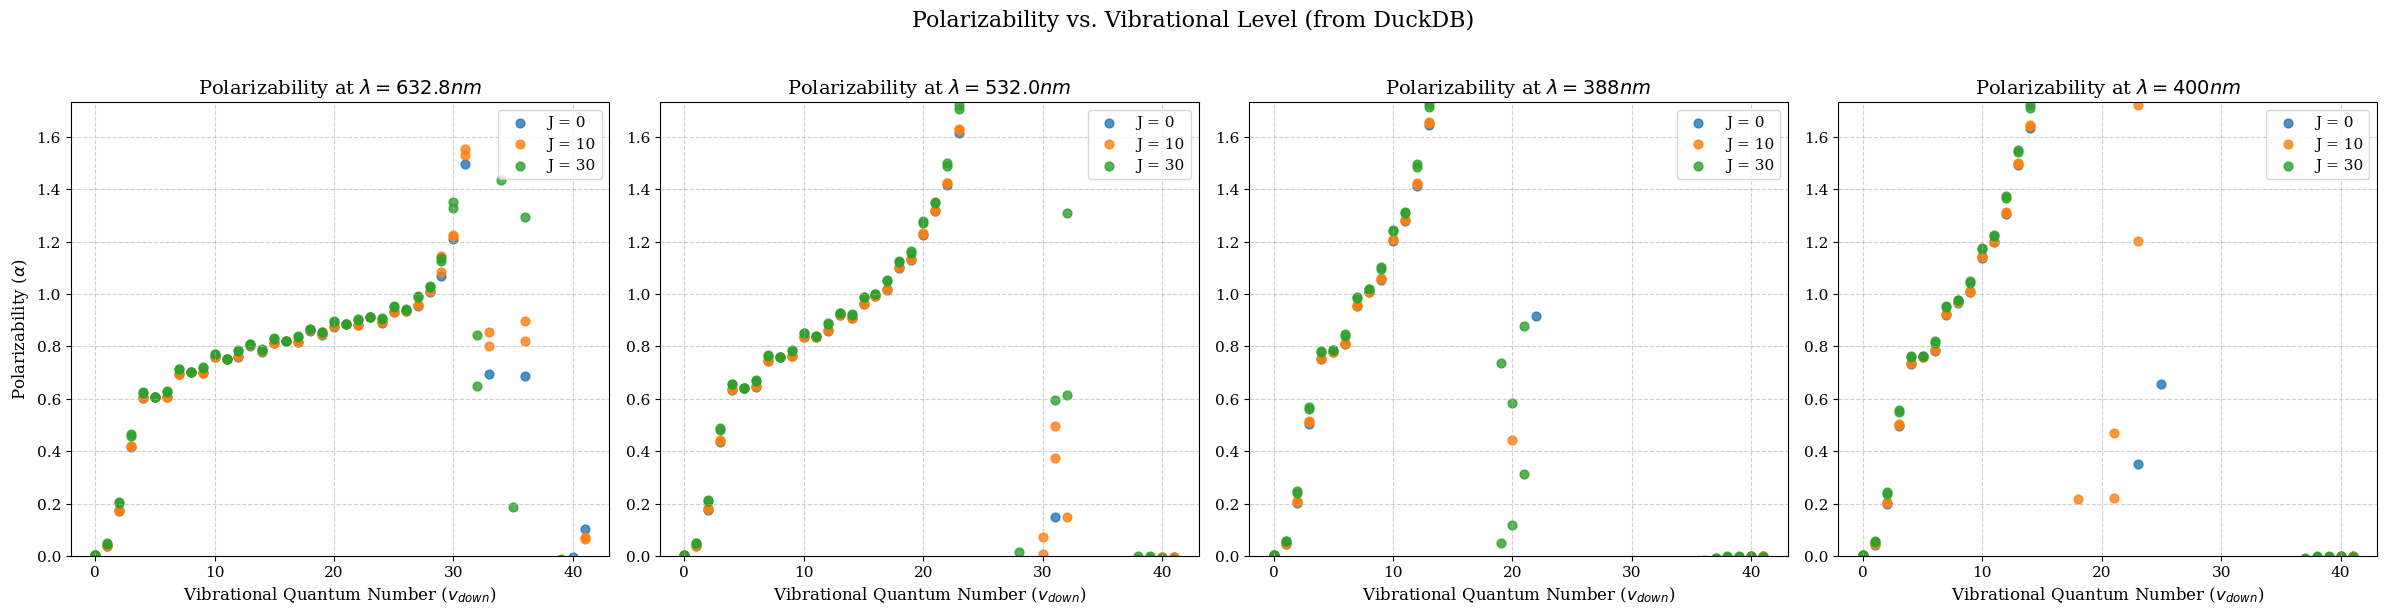

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import duckdb

# --- 1. Setup Plotting Style ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
})

# --- 2. Database Connection and Parameters ---
db_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'
duckdb_conn = duckdb.connect(db_path)

# Ensure these match the exact column names in your DuckDB table
wavelength_keys = ['pol_632.8nm', 'pol_532.0nm', 'pol_388nm', 'pol_400nm']
target_Js = [0, 10, 30]
extracted_plot_data = []

# --- 3. Setup the Plotting Environment ---
fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=False)

# Loop through each wavelength (each subplot)
for i, pol_key in enumerate(wavelength_keys):
    ax = axes[i]
    wv_label = pol_key.replace("pol_", "")
    
    # Loop through the requested J levels
    for target_J in target_Js:
        
        # --- 4. Fetch filtered data from DuckDB ---
        # We use double quotes for the column name to handle the '.' 
        query = f"""
            SELECT down_v, "{pol_key}" 
            FROM discrete_polarizabilities 
            WHERE down_J = {target_J}
            ORDER BY down_v
        """
        df_filtered = duckdb_conn.execute(query).df()
        
        if not df_filtered.empty:
            v_list = df_filtered['down_v'].values
            alpha_real = df_filtered[pol_key].values # Already multiplied in DB
            
            # Save data for export
            for v, alpha in zip(v_list, alpha_real):
                extracted_plot_data.append({
                    'wavelength': wv_label,
                    'J': target_J,
                    'v': v,
                    'alpha_real': alpha
                })
            
            ax.scatter(v_list, alpha_real, label=f'J = {target_J}', s=40, alpha=0.8)
    
    # --- 5. Formatting the Subplot ---
    ax.set_title(f'Polarizability at $\lambda = {wv_label}$', fontsize=14)
    ax.set_xlabel('Vibrational Quantum Number ($v_{down}$)', fontsize=12)
    
    if i == 0:
        ax.set_ylabel(r'Polarizability ($\alpha$)', fontsize=12)
    
    # Keeping your specific limit
    ax.set_ylim(0.00, 1.733) 
    ax.grid(True, linestyle='--', alpha=0.6, which='major')
    ax.legend()

# --- 6. Cleanup and Save ---
duckdb_conn.close()

plt.suptitle('Polarizability vs. Vibrational Level (from DuckDB)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Optional: Save extracted data
# df_plot_data = pd.DataFrame(extracted_plot_data)
# df_plot_data.to_csv('/path/to/save.csv', index=False)

% Realize that the final part of vibrational levels may be moved into the next chapter, if laser wavelengths are important and I need to show a plot that essentially tries to explain how probing NEAR a resonance moves stuff around. So in addition to having howpolariza vibrational levels at new wavelenghts jump up, I will need to show that the band has an absorption wavelength near it .


In [8]:
# OLD DIRECT COPY PASTE
"""
Before computing the sum, we add relevant columns to each dataframe
"""
epsilon_0 = 8.8541878128e-12  # F/m

k_b = 1.380649e-23  # Boltzmann constant in J/K
h = 6.62607015e-34  # Planck constant in J·s
c = 299792458      # Speed of light in  m/s
me = 9.10938356e-31  # Electron mass in kg
e = 1.602176634e-19  # Elementary charge in C

def main (dfs, T_list, Q_list):
    for T, Q in zip(T_list, Q_list):
        print(f"\n--- Temperature = {T} K | Q = {Q} ---")

        for i, df in enumerate(dfs):
            
            # Dynamic column resolution
            J_lower = 'J_lower' if 'J_lower' in df.columns else 'down_J'
            J_upper = 'J_upper' if 'J_upper' in df.columns else 'up_J'
            A = 'A' if 'A' in df.columns else 'einstein_A'
            line_pos = 'line_pos' if 'line_pos' in df.columns else 'nu'
            energy_col = 'e_lower' if 'e_lower' in df.columns else 'down_energy'


            df[energy_col] = (df[energy_col] -2.8739)/0.01 # Converted from cm^-1 to m^-1
            df[line_pos] = df[line_pos]/0.01  # Converted from cm^-1 to m^-1
            df['omega'] = 2*np.pi*c*df[line_pos]
            sensing_omega = sensing_nu * 2 * np.pi * c
            # Compute population (unitless)
            # Convert energy from cm^-1 to J: E_lower * h * c, where c is in cm/s
            pop_string = f'pop_{T}'

            pop_string = ((2 * df[J_lower] + 1) * np.exp(-(df[energy_col] * h * c) / (kB * T))) / Q
            
            
            
            # Convert Einstein A to oscillator strength

            # multiplier = 8*(np.pi)* epsilon_0* me * c**3  /   (e**2)  # SI units  , 8pi^2 may be replaced by 2pi to check for solid angle error
            # multiplier = 2*(np.pi)* epsilon_0* me * c**3  /   (e**2)  # SI units  , 8pi^2 may be replaced by 2pi to check for solid angle error
            df['g2_over_g1'] = (2 * df[J_upper] + 1)/(2 * df[J_lower] + 1)  # degeneracy factor - upper state over lower state, - A21
            # df['g2_over_g1']=1
            

            multiplier = 2*np.pi* epsilon_0 * me * c**3 / e**2  # SI angular frequency form
            
            # df['oscillator_strength'] = (multiplier * df[A] * df['g2_over_g1'] / (df['omega'] ** 2))
            oscillator_strength = (multiplier * df[A] * df['g2_over_g1'] )/ ((df['omega'] ** 2) )

            gamma =0 

            gamma = 2 * np.pi * c * gamma*100  # Convert gamma to angular frequency
            denominator_1 = df['omega'] - sensing_omega  - (1j * gamma / 2)
            denominator_2 = df['omega'] + sensing_omega  + (1j * gamma / 2)
            denominator = denominator_1 * denominator_2
            


            # df['denominator'] =  (df[line_pos]* c)**2  -   (sensing_nu* c)**2 # Hertz^2
            
            df[f'contribution_{T}'] = oscillator_strength * pop_string / denominator


            # df['contribution'] = df['contribution'] * e**2 / me  # Convert to SI units (F·m²)
            # Sort by absolute value of contribution (for convergence)
            # df_sorted = df.reindex(df['contribution'].abs().sort_values(ascending=False).index)
    

    return df


T_list = [3000.0,1200,1700,300.0]  # Temperatures to loop over
Q_list = [4266, 1030, 1703, 219.6]

dfs = main(dfs, [(T_list[3])], [(Q_list[3])])
dfs


--- Temperature = 300.0 K | Q = 219.6 ---


,idx,line_pos,A,Strength,up_el,up_v,up_J,up_lambda,up_sigma,up_omega,...,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,Intensity,omega,g2_over_g1,contribution_300.0
0,0,5465951.27,1.026801e+03,6.014618e-05,B3Sigma-,9,1.0,0.0,-1.0,-1.0,...,0,0.0,0.0,0.0,0.0,0.00,1.926987e-22,1.029595e+16,3.00000,7.245231e-41+0.000000e+ 00j
1,1,5510507.11,1.499359e+03,8.571365e-05,B3Sigma-,10,1.0,0.0,-1.0,-1.0,...,0,0.0,0.0,0.0,0.0,0.00,2.768513e-22,1.037988e+16,3.00000,1.022660e-40+0.000000e+ 00j
2,2,5703784.41,1.363856e+03,7.030697e-05,B3Sigma-,18,1.0,0.0,-1.0,-1.0,...,0,0.0,0.0,0.0,0.0,0.00,2.350533e-22,1.074394e+16,3.00000,8.056100e-41+0.000000e+ 00j
3,3,5314288.56,1.820051e+02,1.160025e-05,B3Sigma-,6,1.0,0.0,-1.0,-1.0,...,0,0.0,0.0,0.0,0.0,0.00,3.613410e-23,1.001027e+16,3.00000,1.444873e-41+0.000000e+ 00j
4,4,5663019.15,3.459317e+03,1.822071e-04,B3Sigma-,15,1.0,0.0,-1.0,-1.0,...,0,0.0,0.0,0.0,0.0,0.00,6.048089e-22,1.066715e+16,3.00000,2.105370e-40+0.000000e+ 00j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494977,711683,739998.24,2.031837e-28,3.373471e-31,B3Sigma-,0,105.0,0.0,-1.0,-1.0,...,39,106.0,0.0,0.0,0.0,5029744.70,1.891254e-57,1.393899e+15,0.99061,-1.338578e-171-0.000000e+ 00j
494978,711725,562913.76,6.328905e-04,2.387169e-06,B3Sigma-,0,105.0,0.0,-1.0,-1.0,...,38,106.0,0.0,1.0,1.0,5206829.18,5.024372e-33,1.060333e+15,0.99061,-1.320257e-150-0.000000e+ 00j
494979,711778,496044.13,2.204197e-29,1.214982e-31,B3Sigma-,0,105.0,0.0,-1.0,-1.0,...,40,106.0,0.0,0.0,0.0,5273698.81,1.698411e-58,9.343743e+14,0.99061,-2.321368e-177-0.000000e+ 00j
494980,711824,230056.70,2.344806e-05,1.295634e-06,B3Sigma-,0,105.0,0.0,-1.0,-1.0,...,41,106.0,0.0,0.0,0.0,5539686.24,2.182729e-34,4.333467e+14,0.99061,-3.048603e-158-0.000000e+ 00j


In [15]:
epsilon_0 = 8.8541878128e-12  # F/m

pol = dfs['contribution_300.0'].sum()
pol = pol * e**2 / me  # Convert to SI units (F·m²)
(pol*1e30/(epsilon_0)).real  # Convert to Å³ 
# (pol*3/(4*np.pi*epsilon_0) *1e30)  # Convert to Å³
# # Compute converged α
#         contributions = df_sorted['contribution'].values
#         partial_sum = 0.0 
#         prev_sum = 0.0 
#         print (contributions.sum()/(4*np.pi*epsilon_0) *1e30)  # Convert to Å³

# MAYBE GO BACK TO THE ORIGINAL FORMULA WHICH HAD SOME FACTOR? 

TypeError: list indices must be integers or slices, not str